In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import numpy as np
import math
from matplotlib.scale import FuncScale

from pathlib import Path

from os.path import join
import os
from functools import partial
import pathlib
import shutil

import re

import multiprocessing as mp
from credit.datasets.goes_load_dataset_and_dataloader import load_verification_dataset
from credit.pbs import get_num_cpus
import yaml

import pandas as pd
from scores.spatial import fss_2d, fss_2d_binary



In [2]:
num_cpus = get_num_cpus()

print(num_cpus)

2


In [3]:
config = "/glade/u/home/dkimpara/miles-credit/config_goes/example_eval.yml"
# verif_dir = "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts"
verif_dir = "/glade/derecho/scratch/dkimpara/goes_10km_train/mpas/mpas_fixed_test/"
verif_dirs = [p for p in Path(verif_dir).iterdir() if p.is_dir() and p.name != "gifs"]


In [4]:
verif_dir = verif_dirs[0]
print(verif_dir)

forecast_files = sorted(list(verif_dir.iterdir()))


/glade/derecho/scratch/dkimpara/goes_10km_train/mpas/mpas_fixed_test/2025-07-05T17:55:00


In [5]:
# Load the configuration and get the relevant variables
with open(config) as cf:
    conf = yaml.load(cf, Loader=yaml.FullLoader)
# get the model config
with open(conf["config"]) as cf:
    model_conf = yaml.load(cf, Loader=yaml.FullLoader)

dataset = load_verification_dataset(model_conf, conf)


loading dataset for with 0 forecast steps! only for eval


In [6]:
def get_pred_true_das(f):
    pred_da = xr.open_dataset(f)["BT_or_R"] # BT_or_R with t channel lat lon 
    true_da = dataset[pred_da.t[0].values, "y"]["y"]
    return true_da, pred_da.isel(t=0)

def is_in_bin(da, bin_edges):
    """
    outputs a masked dataarray of where the values are within the bin_edges
    """
    return (bin_edges[0] < da) & (da <= bin_edges[1])

In [21]:
target_da, pred_da = get_pred_true_das(forecast_files[12])
bin_edges = [210, 235]
window_size = 100


target_da = target_da.sel(channel=13)
pred_da = pred_da.sel(channel=13)

target_sorted = np.sort(target_da.values.flatten())
num_idxs = len(target_sorted)

def find_quantile_target(thresholds):
    idxs = np.searchsorted(target_sorted, thresholds)
    return idxs / num_idxs

def find_pred_pct_thresholds(thresholds):
    quantiles = find_quantile_target(thresholds)
    pred_pct_thresholds = pred_da.quantile(quantiles)
    return pred_pct_thresholds


bin_edges_pred = find_pred_pct_thresholds(bin_edges) # get corresponding value at equiv percentile
pred_binary = is_in_bin(pred_da, bin_edges_pred.values)
print(bin_edges_pred.values)

target_binary = is_in_bin(target_da, bin_edges)

fss = fss_2d_binary(pred_binary, target_binary,
        window_size=(window_size, window_size),
        spatial_dims=("latitude", "longitude"),
        )

[222.02646649 243.03126977]


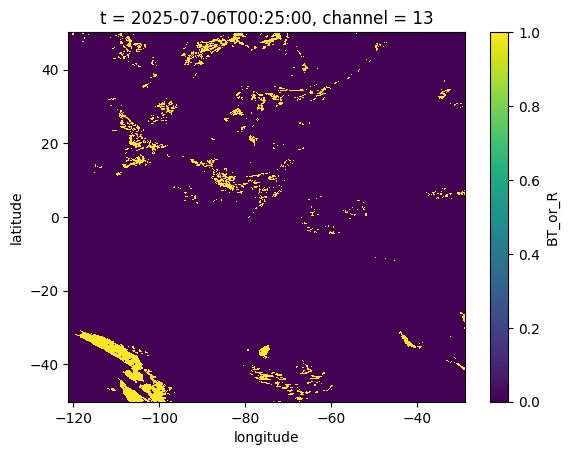

In [23]:
pred_binary.plot()

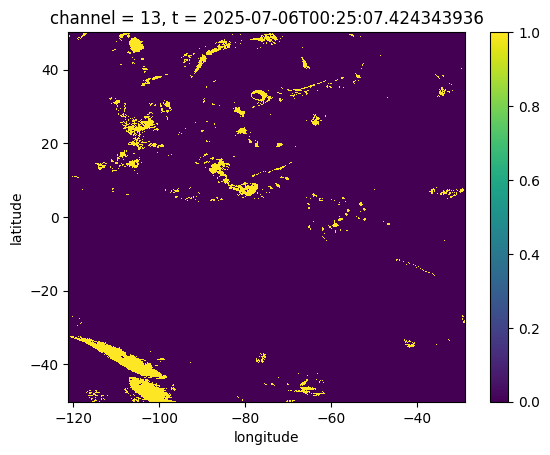

In [24]:
target_binary.plot()